#Feature Engineering

##Handle Missing Value

In [1]:
import pandas as pd 
import numpy as np 

In [2]:
def titanic_data(TITANIC_PATH):
    return pd.read_csv(TITANIC_PATH)

titanic = pd.read_csv("titanic.csv")
titanic.head(50)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
titanic['Name'].value_counts()

Name
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
Allen, Mr. William Henry                               1
                                                      ..
Montvila, Rev. Juozas                                  1
Graham, Miss. Margaret Edith                           1
Johnston, Miss. Catherine Helen "Carrie"               1
Behr, Mr. Karl Howell                                  1
Dooley, Mr. Patrick                                    1
Name: count, Length: 891, dtype: int64

In [5]:
titanic['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [8]:
titanic['Ticket'].value_counts()
# titanic['Cabin'].value_counts()
# titanic['Embarked'].value_counts()

Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
373450              1
STON/O2. 3101282    1
Name: count, Length: 681, dtype: int64

In [9]:
titanic['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [10]:
titanic['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [11]:
df = pd.DataFrame(titanic)
print("Original DataFrame with Missing Values:")
print(df)

Original DataFrame with Missing Values:
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                           

In [12]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [14]:
mean_age = df['Age'].mean()
mean_age = round(mean_age)
print("Mean of ages = ", mean_age)

Mean of ages =  30


In [16]:
df['Age'].fillna(mean_age, inplace=True)

C:\Users\shres\AppData\Local\Temp\ipykernel_9732\3636672125.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(mean_age, inplace=True)


In [17]:
print(df['Age'].isnull().sum())

0


In [18]:
titanic_new = titanic.drop(columns= "Cabin")

In [20]:
titanic_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [22]:
df = pd.DataFrame(titanic_new)
df.head(50)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,30.0,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


##Handle Categorial Values

In [23]:
mode_titanic = df['Embarked'].mode()
print("Mode from Embarked of titanic = ", mode_titanic[0])

Mode from Embarked of titanic =  S


In [24]:
df['Embarked'].fillna(mode_titanic[0], inplace=True)

In [27]:
print(df['Embarked'].isnull().sum())

0


##Data Scaling

In [28]:
df['Fare'] = df['Fare'] * 10000

In [29]:
df['Fare'].head(10)

0     72500.0
1    712833.0
2     79250.0
3    531000.0
4     80500.0
5     84583.0
6    518625.0
7    210750.0
8    111333.0
9    300708.0
Name: Fare, dtype: float64

here, the data of column 'Fare' is increased by 1000 times so that we can use it in data scale.

In [36]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

# Initialize scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
maxabs_scaler = MaxAbsScaler()

# Apply scalers
df_standard = pd.DataFrame(standard_scaler.fit_transform(df[["Fare"]]), columns=["Fare"])
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df[["Fare"]]), columns=["Fare"])
df_robust = pd.DataFrame(robust_scaler.fit_transform(df[["Fare"]]), columns=["Fare"])
df_maxabs = pd.DataFrame(maxabs_scaler.fit_transform(df[["Fare"]]), columns=["Fare"])

# Log Transformation (Handling zero by adding 1)
df_log = np.log1p(df["Fare"])

# Display results
print("\nStandard Scaled Data:\n", df_standard)
print("\nMinMax Scaled Data:\n", df_minmax)


Standard Scaled Data:
          Fare
0   -0.502445
1    0.786845
2   -0.488854
3    0.420730
4   -0.486337
..        ...
886 -0.386671
887 -0.044381
888 -0.176263
889 -0.044381
890 -0.492378

[891 rows x 1 columns]

MinMax Scaled Data:
          Fare
0    0.014151
1    0.139136
2    0.015469
3    0.103644
4    0.015713
..        ...
886  0.025374
887  0.058556
888  0.045771
889  0.058556
890  0.015127

[891 rows x 1 columns]


In [37]:
print("\nRobust Scaled Data:\n", df_robust)
print("\nMaxAbs Scaled Data:\n", df_maxabs)


Robust Scaled Data:
          Fare
0   -0.312011
1    2.461242
2   -0.282777
3    1.673732
4   -0.277363
..        ...
886 -0.062981
887  0.673281
888  0.389604
889  0.673281
890 -0.290356

[891 rows x 1 columns]

MaxAbs Scaled Data:
          Fare
0    0.014151
1    0.139136
2    0.015469
3    0.103644
4    0.015713
..        ...
886  0.025374
887  0.058556
888  0.045771
889  0.058556
890  0.015127

[891 rows x 1 columns]


In [38]:
print("\nLog Transformed Data:\n", df_log)


Log Transformed Data:
 0      11.191356
1      13.477004
2      11.280375
3      13.182519
4      11.296025
         ...    
886    11.775297
887    12.611541
888    12.365215
889    12.611541
890    11.258046
Name: Fare, Length: 891, dtype: float64


##Handling Outliers

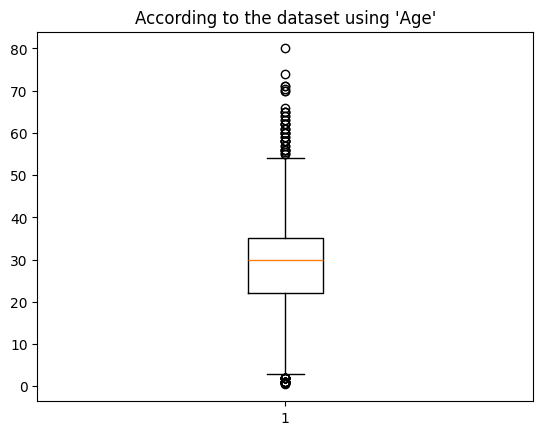

In [65]:
import matplotlib.pyplot as plt

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

plt.boxplot(df['Age'])
plt.title("According to the dataset using 'Age'")

plt.show()

Here, many outliers are there which is effect our output. So removing them.

In [54]:
print(f"Q1 = {Q1} and Q3 = {Q3}")

Q1 = 22.0 and Q3 = 35.0


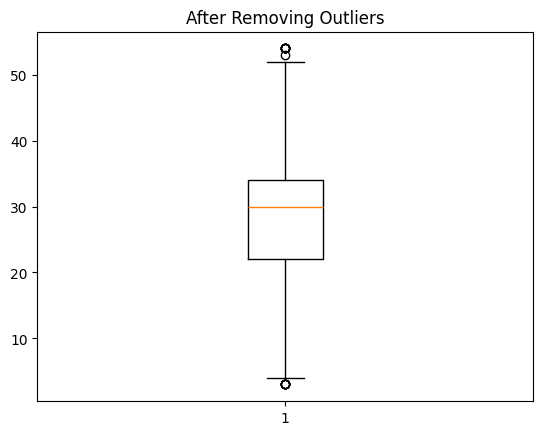

In [66]:

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

plt.boxplot(df_filtered['Age'])
plt.title("After Removing Outliers")

plt.show()

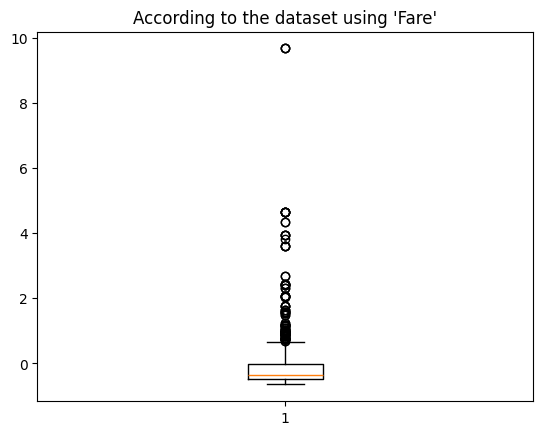

In [67]:
Q11 = df_standard['Fare'].quantile(0.25)
Q13 = df_standard['Fare'].quantile(0.75)
IQR1 = Q13 - Q11

plt.boxplot(df_standard['Fare'])
plt.title("According to the dataset using 'Fare'")

plt.show()

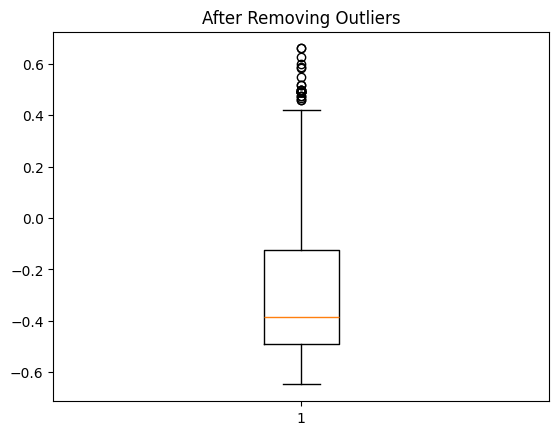

In [68]:

lower_bound = Q11 - 1.5 * IQR1
upper_bound = Q13 + 1.5 * IQR1

df_filtered_Fare = df_standard[(df_standard['Fare'] >= lower_bound) & (df_standard['Fare'] <= upper_bound)]

plt.boxplot(df_filtered_Fare['Fare'])
plt.title("After Removing Outliers")

plt.show()

In [70]:
titanic_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [85]:
titanic_new_1 = titanic_new.drop(columns= "Name")

In [86]:
titanic_new_1 = titanic_new_1.drop(columns= "Sex")

In [88]:
titanic_new_1 = titanic_new_1.drop(columns= "Ticket")

In [89]:
titanic_new_1 = titanic_new_1.drop(columns= "Embarked")

In [90]:
titanic_new_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 48.9 KB


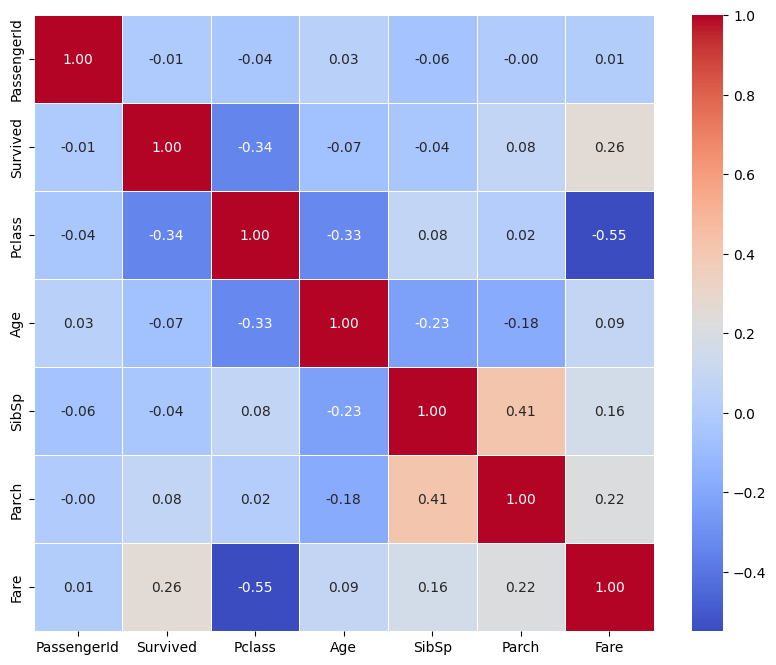

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [103]:
import seaborn as sns

corr_matrix = titanic_new_1.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.show()

corr_threshold = 0.9
to_drop = [column for column in corr_matrix.columns if any(abs(corr_matrix[column]) > corr_threshold)]
print(to_drop)

X = titanic.drop("Fare", axis=1)
y = titanic['Fare']

In [104]:
titanic_num = X.select_dtypes(include=['float64', 'int64']).columns
titanic_cat = X.select_dtypes(include=['object']).columns

# Print out the column names to verify
print("Numerical columns:", titanic_num)
print("Categorical columns:", titanic_cat)

Numerical columns: Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch'], dtype='object')
Categorical columns: Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


In [105]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


from sklearn.impute import SimpleImputer

## Define the numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values with median
    ('scaler', StandardScaler())  # Scale the numerical features
])

# Define the categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing categorical values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encode categorical features
])

# Combine both pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), titanic_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), titanic_cat)
    ]
)


In [101]:
# Apply the transformation to the features (X)
X_transformed = preprocessor.fit_transform(X)

num_columns = titanic_num

cat_columns = preprocessor.named_transformers_["cat"].get_feature_names_out(titanic_cat)

all_columns = list(num_columns) + list(cat_columns)
X_transformed_df = pd.DataFrame(X_transformed, columns=all_columns)

# Display the transformed dataset
print(X_transformed_df.head())

   PassengerId  Survived    Pclass       Age     SibSp     Parch      Fare  \
0    -1.730108 -0.789272  0.827377 -0.597055  0.432793 -0.473674 -0.502445   
1    -1.726220  1.266990 -1.566107  0.634162  0.432793 -0.473674  0.786845   
2    -1.722332  1.266990  0.827377 -0.289251 -0.474545 -0.473674 -0.488854   
3    -1.718444  1.266990 -1.566107  0.403309  0.432793 -0.473674  0.420730   
4    -1.714556 -0.789272  0.827377  0.403309 -0.474545 -0.473674 -0.486337   

   Name_Abbing, Mr. Anthony  Name_Abbott, Mr. Rossmore Edward  \
0                       0.0                               0.0   
1                       0.0                               0.0   
2                       0.0                               0.0   
3                       0.0                               0.0   
4                       0.0                               0.0   

   Name_Abbott, Mrs. Stanton (Rosa Hunt)  ...  Cabin_F33  Cabin_F38  Cabin_F4  \
0                                    0.0  ...        0.0   

In [106]:
X = X_transformed_df

from sklearn.linear_model import LassoCV 
from sklearn.model_selection import train_test_split
# Create a LassoCV model
lasso = LassoCV(cv=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Fit the model to the training data
lasso.fit(X_train, y_train)


# Print the best alpha value chosen by cross-validation
print(f"Best alpha: {lasso.alpha_}")
# Get the features selected by Lasso
selected_features = X.columns[lasso.coef_ != 0]
print(f"Selected features: {selected_features}")

Best alpha: 0.25205697976524877
Selected features: Index(['Fare'], dtype='object')


##PCA

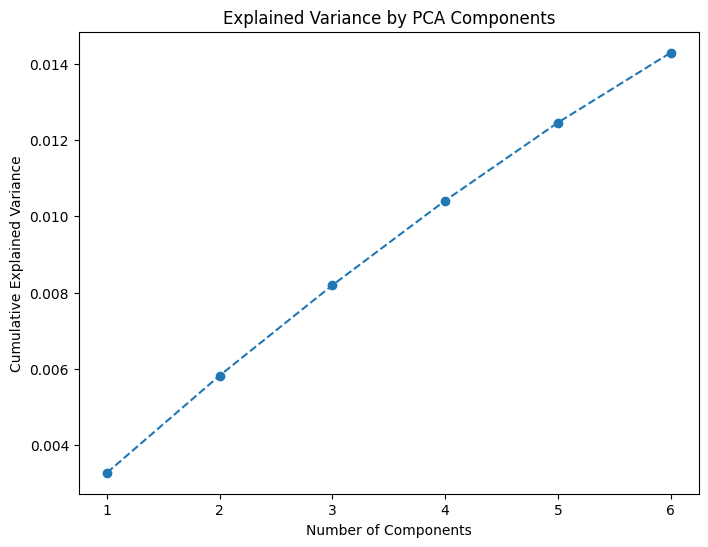

In [110]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

imputer = SimpleImputer(strategy="mean")  
scaled_data = imputer.fit_transform(scaled_data)

pca = PCA(n_components=6)  
pca_features = pca.fit_transform(scaled_data)

# Convert to DataFrame
pca_df = pd.DataFrame(pca_features, columns=[f'PC{i+1}' for i in range(6)])

explained_variance = pca.explained_variance_ratio_

# Plot cumulative variance
plt.figure(figsize=(8,6))
plt.plot(range(1, len(explained_variance)+1), explained_variance.cumsum(), marker='o', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.show()